In [25]:
# Mounting Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# Imports
import torch
import os
import matplotlib.pyplot as plt
from collections import OrderedDict
from PIL import Image
import matplotlib.pyplot as plt
import random
import sys


# ======================= Import dataset utilities ========================
os.chdir("/content/drive/MyDrive/Colab Notebooks/NVDIA_Project/Image-level-micro-gesture-classification")
from dataset import get_train_loader, get_train_dataset

# ======================= Import model utilities ========================
from models.resnet18_model import build_resnet18

In [27]:
# Connection check to GPU and check if it's available
print(torch.cuda.is_available())
!nvidia-smi

True
Thu Mar 19 16:02:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              8W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

In [28]:
# ------------------ Check the number of class folders in the training directory -------------------
# Note: Update the train_dir path to your dataset location
#       If you want to connect to your Google Drive, you can use the first path, but it is slower than the second path which is directly in the Colab environment.
#       You can copy your dataset to the Colab environment for faster access.
#       In our group, we uploaded the dataset as a ZIP file to the Colab environment, then unzipped it and used the second path for training.


# train_dir = "/content/drive/MyDrive/Colab Notebooks/NVDIA_Project/Image-level-micro-gesture-classification/data/train"
train_dir = "/content/train"

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
# Sort the classe folders to ensure consistent ordering
classes = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))],
    key=int
)
print("Number of class folders:", len(classes))
print(classes)

Number of class folders: 32
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32']


In [29]:
# Check images per class
class_counts = OrderedDict()

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    class_counts[cls] = len(images)

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("Total images:", sum(class_counts.values()))

1: 104
2: 1698
3: 183
4: 634
5: 266
6: 191
7: 306
8: 2060
9: 279
10: 12
11: 2345
12: 1403
13: 327
14: 347
15: 97
16: 163
17: 1963
18: 464
19: 14
20: 4994
21: 686
22: 2290
23: 3588
24: 4025
25: 158
26: 3224
27: 622
28: 219
29: 4618
30: 57
31: 6671
32: 16506
Total images: 60514


In [30]:
# Analyze class distribution
counts = list(class_counts.values())

print("Min images in a class:", min(counts))
print("Max images in a class:", max(counts))
print("Average images per class:", sum(counts) / len(counts))

Min images in a class: 12
Max images in a class: 16506
Average images per class: 1891.0625


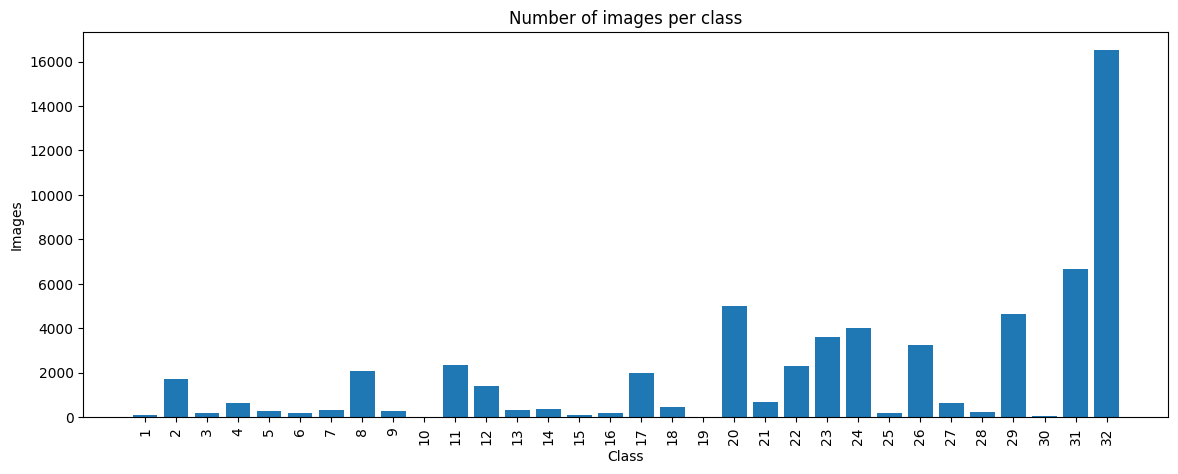

In [31]:
# Visualize class distribution

plt.figure(figsize=(14,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Number of images per class")
plt.xlabel("Class")
plt.ylabel("Images")
plt.show()

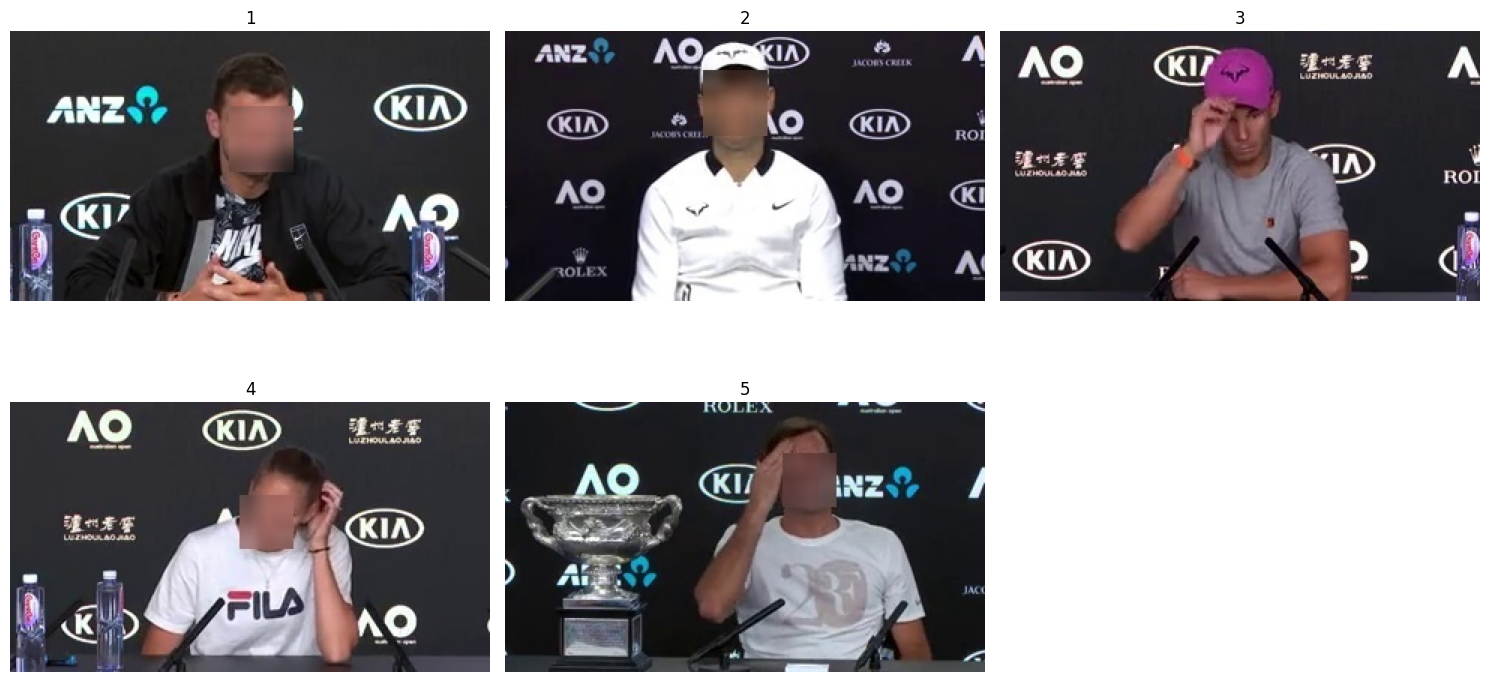

In [32]:
# Visualize sample images from a few classes

sample_classes = classes[:5]

plt.figure(figsize=(15, 8))

for i, cls in enumerate(sample_classes):
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    img_name = random.choice(images)
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
# Step 2: Data Preprocessing - Test the data loader
trainloader, valloader, testloader = get_train_loader(train_dir)

images, labels = next(iter(trainloader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [34]:
# Step 3: Model Selection - Test loading a pre-trained model
model = build_resnet18()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  